In [1]:
#Setup

In [13]:
"""
Notebook 04: Classification Model — "Will it be paid?"
=======================================================
Target: paid_within_90d (binary)
Model: LightGBM with SHAP explainability
Split: Time-based (NOT random)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 100,
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

# ── Load modeling dataset ──
from pathlib import Path

DATA_DIR = Path('C:/Users/Manu/Desktop/Project 2 AR Collections Intelligence Engine/Raw Data')

modeling_df = pd.read_csv(
    DATA_DIR / 'modeling_dataset.csv',
    parse_dates=['observation_date', 'invoice_date', 'due_date']
)

print(f"Dataset loaded: {modeling_df.shape}")
print(f"Target balance: {modeling_df['paid_within_90d'].mean():.1%} positive (paid)")
print(f"Date range: {modeling_df['observation_date'].min().date()} to {modeling_df['observation_date'].max().date()}")

Dataset loaded: (410854, 49)
Target balance: 63.0% positive (paid)
Date range: 2022-02-02 to 2023-12-31


In [14]:
#Define Features and Target

In [15]:
"""
STEP 1: Define feature columns and target
"""

FEATURE_COLUMNS = [
    # Invoice-level
    'invoice_amount', 'log_invoice_amount', 'payment_terms_days',
    'days_past_due', 'days_since_invoice', 'aging_bucket', 'pct_term_elapsed',
    'has_po_number', 'is_recurring', 'line_item_count',

    # Customer historical payment
    'avg_days_to_pay_6m', 'std_days_to_pay_6m', 'median_days_to_pay_6m',
    'on_time_rate_6m', 'payment_count_6m', 'worst_delay_6m',
    'payment_consistency_idx',

    # Dispute
    'has_active_dispute', 'customer_dispute_rate_12m',

    # Dunning
    'contacts_to_date', 'days_since_last_contact', 'has_promise_to_pay',
    'phone_contact_count', 'max_contact_sequence',

    # Portfolio pressure
    'open_invoice_count', 'total_open_ar', 'credit_utilization',
    'amount_vs_credit_limit',

    # Relationship
    'customer_tenure_months',

    # Seasonal
    'is_q1', 'is_quarter_end_month', 'is_year_end',

    # Composite
    'health_score',

    # Encoded categoricals
    'risk_tier_encoded',
    'seg_Mid-Market', 'seg_SMB',
    'region_North', 'region_South', 'region_West',
    'is_manufacturing', 'is_it_services', 'is_retail',
]

# Keep only features that exist in the dataset
FEATURES = [c for c in FEATURE_COLUMNS if c in modeling_df.columns]
TARGET = 'paid_within_90d'

missing = [c for c in FEATURE_COLUMNS if c not in modeling_df.columns]
if missing:
    print(f"⚠ Missing features (skipped): {missing}")

print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")

Features: 42
Target: paid_within_90d


In [16]:
#Time-Based Train / Validation / Test Split

In [17]:
"""
STEP 2: TIME-BASED SPLIT

WHY NOT RANDOM SPLIT:
In production, you always predict FORWARD in time. A random split
would let the model train on Nov 2023 data and test on Jan 2023 data,
leaking future information.

Split:
  Train: observation_date <= 2023-06-30 (18 months)
  Val:   observation_date Jul-Sep 2023 (3 months)
  Test:  observation_date Oct-Dec 2023 (3 months)
"""

train_mask = modeling_df['observation_date'] <= '2023-06-30'
val_mask = (modeling_df['observation_date'] > '2023-06-30') & (modeling_df['observation_date'] <= '2023-09-30')
test_mask = modeling_df['observation_date'] > '2023-09-30'

X_train = modeling_df.loc[train_mask, FEATURES]
y_train = modeling_df.loc[train_mask, TARGET]

X_val = modeling_df.loc[val_mask, FEATURES]
y_val = modeling_df.loc[val_mask, TARGET]

X_test = modeling_df.loc[test_mask, FEATURES]
y_test = modeling_df.loc[test_mask, TARGET]

print(f"Train: {len(X_train):>8,} rows  ({y_train.mean():.1%} positive)  "
      f"[{modeling_df.loc[train_mask, 'observation_date'].min().date()} → "
      f"{modeling_df.loc[train_mask, 'observation_date'].max().date()}]")
print(f"Val:   {len(X_val):>8,} rows  ({y_val.mean():.1%} positive)  "
      f"[{modeling_df.loc[val_mask, 'observation_date'].min().date()} → "
      f"{modeling_df.loc[val_mask, 'observation_date'].max().date()}]")
print(f"Test:  {len(X_test):>8,} rows  ({y_test.mean():.1%} positive)  "
      f"[{modeling_df.loc[test_mask, 'observation_date'].min().date()} → "
      f"{modeling_df.loc[test_mask, 'observation_date'].max().date()}]")

# Class imbalance ratio
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count
print(f"\nClass imbalance ratio (neg/pos): {imbalance_ratio:.2f}")
print(f"  → Will use scale_pos_weight={imbalance_ratio:.2f} in LightGBM")

Train:  273,311 rows  (66.1% positive)  [2022-02-02 → 2023-06-30]
Val:     67,343 rows  (64.0% positive)  [2023-07-01 → 2023-09-30]
Test:    70,200 rows  (50.0% positive)  [2023-10-01 → 2023-12-31]

Class imbalance ratio (neg/pos): 0.51
  → Will use scale_pos_weight=0.51 in LightGBM


In [18]:
#Baseline Model — Logistic Regression

In [19]:
"""
STEP 3: BASELINE MODEL — Logistic Regression

Always start with a simple baseline. This gives you:
  1. A benchmark to beat
  2. Confirmation that features have predictive signal
  3. A sanity check (if LR gets 0.99 AUC, you have leakage)
"""

from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

baseline.fit(X_train, y_train)

# Predictions
y_val_pred_lr = baseline.predict_proba(X_val)[:, 1]
y_val_class_lr = baseline.predict(X_val)

# Metrics
print("BASELINE: Logistic Regression")
print("=" * 50)
print(f"  AUC-ROC:    {roc_auc_score(y_val, y_val_pred_lr):.4f}")
print(f"  AUC-PR:     {average_precision_score(y_val, y_val_pred_lr):.4f}")
print(f"  F1:         {f1_score(y_val, y_val_class_lr):.4f}")
print(f"  Accuracy:   {accuracy_score(y_val, y_val_class_lr):.4f}")
print(f"  Precision:  {precision_score(y_val, y_val_class_lr):.4f}")
print(f"  Recall:     {recall_score(y_val, y_val_class_lr):.4f}")
print(f"  Brier:      {brier_score_loss(y_val, y_val_pred_lr):.4f}")

# Feature importance from LR coefficients
lr_coefs = pd.Series(
    baseline.named_steps['model'].coef_[0],
    index=FEATURES
).abs().sort_values(ascending=False)
print(f"\nTop 10 features (by |coefficient|):")
for feat, coef in lr_coefs.head(10).items():
    print(f"  {feat:35s}: {coef:.4f}")

BASELINE: Logistic Regression
  AUC-ROC:    0.7631
  AUC-PR:     0.8363
  F1:         0.7282
  Accuracy:   0.6810
  Precision:  0.8011
  Recall:     0.6675
  Brier:      0.2074

Top 10 features (by |coefficient|):
  days_past_due                      : 1.2124
  pct_term_elapsed                   : 0.9418
  days_since_invoice                 : 0.7022
  days_since_last_contact            : 0.6940
  open_invoice_count                 : 0.6938
  payment_terms_days                 : 0.5680
  customer_tenure_months             : 0.4442
  aging_bucket                       : 0.4112
  avg_days_to_pay_6m                 : 0.2669
  seg_Mid-Market                     : 0.2457


In [20]:
#LightGBM Model

In [25]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 7.4 MB/s eta 0:00:00


In [26]:
"""
STEP 4: LightGBM MODEL

Why LightGBM:
  - Handles mixed types (categorical + numerical) well
  - Fast training, good for iteration
  - Captures non-linear interactions naturally
  - Works well with moderate class imbalance
"""

# Install if needed: pip install lightgbm
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    boosting_type='gbdt',
    n_estimators=1000,
    num_leaves=63,
    learning_rate=0.05,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    scale_pos_weight=imbalance_ratio,
    min_child_samples=50,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(100),
    ]
)

# Predictions
y_val_pred_lgb = lgb_model.predict_proba(X_val)[:, 1]
y_val_class_lgb = lgb_model.predict(X_val)

print("\nLIGHTGBM MODEL")
print("=" * 50)
print(f"  AUC-ROC:    {roc_auc_score(y_val, y_val_pred_lgb):.4f}")
print(f"  AUC-PR:     {average_precision_score(y_val, y_val_pred_lgb):.4f}")
print(f"  F1:         {f1_score(y_val, y_val_class_lgb):.4f}")
print(f"  Accuracy:   {accuracy_score(y_val, y_val_class_lgb):.4f}")
print(f"  Precision:  {precision_score(y_val, y_val_class_lgb):.4f}")
print(f"  Recall:     {recall_score(y_val, y_val_class_lgb):.4f}")
print(f"  Brier:      {brier_score_loss(y_val, y_val_pred_lgb):.4f}")
print(f"  Best iteration: {lgb_model.best_iteration_}")

# Improvement over baseline
lr_auc = roc_auc_score(y_val, y_val_pred_lr)
lgb_auc = roc_auc_score(y_val, y_val_pred_lgb)
print(f"\n  Improvement over LR baseline: +{(lgb_auc - lr_auc):.4f} AUC")

  File "C:\Users\Manu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Manu\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Manu\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Manu\anaconda3\Lib\subprocess.py",

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.789235
[200]	valid_0's auc: 0.7937
[300]	valid_0's auc: 0.794541
[400]	valid_0's auc: 0.794825
Early stopping, best iteration is:
[356]	valid_0's auc: 0.794942

LIGHTGBM MODEL
  AUC-ROC:    0.7949
  AUC-PR:     0.8653
  F1:         0.7660
  Accuracy:   0.7158
  Precision:  0.8100
  Recall:     0.7266
  Brier:      0.1838
  Best iteration: 356

  Improvement over LR baseline: +0.0318 AUC


In [27]:
#Hyperparameter Tuning with Optuna

In [29]:
pip install optuna


   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]

Note: you may need to restart the kernel to use updated packages.


In [30]:
"""
STEP 5: HYPERPARAMETER TUNING WITH OPTUNA

Bayesian optimization — smarter than grid search.
50 trials is usually enough for a good set of hyperparameters.
"""

# Install if needed: pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_estimators': 1000,
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 5,
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': imbalance_ratio,
        'random_state': 42,
        'verbose': -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    y_pred = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred)

print("Running Optuna hyperparameter tuning (50 trials)...")
print("This may take 5-10 minutes...\n")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC-ROC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Running Optuna hyperparameter tuning (50 trials)...
This may take 5-10 minutes...



  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC-ROC: 0.7973
Best params:
  num_leaves: 118
  learning_rate: 0.012792393236858355
  feature_fraction: 0.7405816236453371
  bagging_fraction: 0.7628251976449195
  min_child_samples: 51
  reg_alpha: 0.47152541882803367
  reg_lambda: 1.2643278485614449


In [31]:
#Retrain with Best Params

In [34]:
"""
STEP 6: RETRAIN WITH BEST HYPERPARAMETERS
"""

best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'bagging_freq': 5,
    'scale_pos_weight': imbalance_ratio,
    'random_state': 42,
    'verbose': -1,
})

best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

y_val_pred = best_model.predict_proba(X_val)[:, 1]
y_test_pred = best_model.predict_proba(X_test)[:, 1]

print("TUNED LIGHTGBM — VALIDATION SET")
print("=" * 50)
print(f"  AUC-ROC:  {roc_auc_score(y_val, y_val_pred):.4f}")
print(f"  AUC-PR:   {average_precision_score(y_val, y_val_pred):.4f}")
print(f"  Brier:    {brier_score_loss(y_val, y_val_pred):.4f}")

TUNED LIGHTGBM — VALIDATION SET
  AUC-ROC:  0.7973
  AUC-PR:   0.8672
  Brier:    0.1831


In [35]:
#Threshold Selection

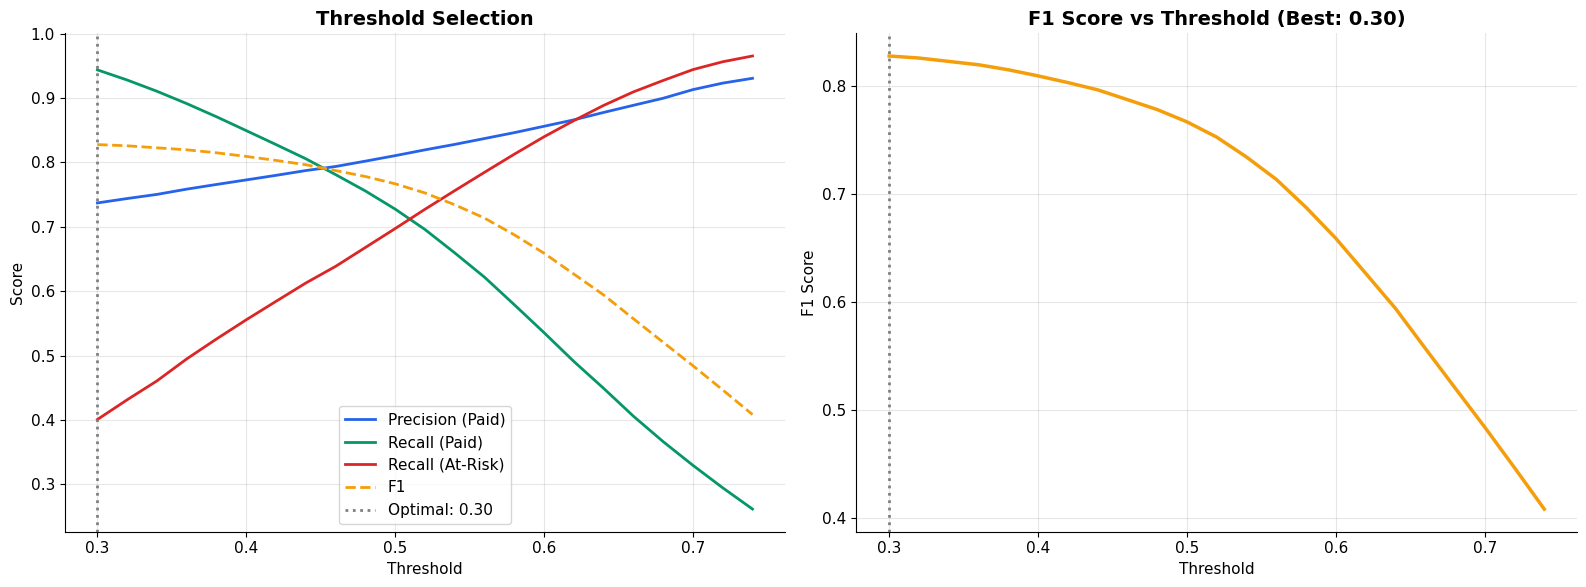


Optimal threshold: 0.30

Metrics at optimal threshold:
  f1                  : 0.8277
  precision           : 0.7371
  recall              : 0.9438
  recall_at_risk      : 0.4007
  accuracy            : 0.7484


In [36]:
"""
STEP 7: THRESHOLD SELECTION

Default threshold 0.5 is rarely optimal.
In collections, RECALL matters more — you'd rather flag 10 invoices
that didn't need attention than miss 5 that were going to default.

Strategy: Find threshold where recall >= 0.80 for the at-risk class (class 0)
"""

# Note: "at-risk" = class 0 (NOT paid within 90 days)
# We want high recall on class 0 = catching invoices that won't be paid

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_pred)

# For the at-risk class (class 0), we need to flip:
# high recall on class 0 means LOW threshold (flag more as "not paid")
precisions_0, recalls_0, thresholds_0 = precision_recall_curve(
    1 - y_val, 1 - y_val_pred  # flip classes
)

# Find best F1 threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 0.5

# Also try: threshold that maximizes recall for class 0 while keeping precision > 0.5
# This means: lower the threshold so more invoices are flagged as "will be paid"
# and the ones NOT flagged (predicted as not-paid) have high recall

# Simpler approach: test a range and pick best F1
threshold_results = []
for thresh in np.arange(0.3, 0.75, 0.02):
    y_pred_t = (y_val_pred >= thresh).astype(int)
    threshold_results.append({
        'threshold': thresh,
        'f1': f1_score(y_val, y_pred_t),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall': recall_score(y_val, y_pred_t),
        'accuracy': accuracy_score(y_val, y_pred_t),
        # Recall on class 0 (at-risk invoices caught)
        'recall_at_risk': recall_score(y_val, y_pred_t, pos_label=0),
    })

thresh_df = pd.DataFrame(threshold_results)

# Best threshold: maximize F1
optimal_threshold = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision (Paid)', color='#2563EB', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall (Paid)', color='#059669', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall_at_risk'], label='Recall (At-Risk)', color='#DC2626', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'], label='F1', color='#F59E0B', linewidth=2, linestyle='--')
ax.axvline(x=optimal_threshold, color='gray', linestyle=':', linewidth=2, label=f'Optimal: {optimal_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Selection')
ax.legend()

ax = axes[1]
ax.plot(thresh_df['threshold'], thresh_df['f1'], color='#F59E0B', linewidth=2.5)
ax.axvline(x=optimal_threshold, color='gray', linestyle=':', linewidth=2)
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title(f'F1 Score vs Threshold (Best: {optimal_threshold:.2f})')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}threshold_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"\nMetrics at optimal threshold:")
best_row = thresh_df.loc[thresh_df['f1'].idxmax()]
for col in ['f1', 'precision', 'recall', 'recall_at_risk', 'accuracy']:
    print(f"  {col:20s}: {best_row[col]:.4f}")

In [37]:
#Evaluate on Test Set

FINAL RESULTS — TEST SET
  Threshold:  0.30
  AUC-ROC:    0.7445
  AUC-PR:     0.7457
  F1:         0.7146
  Precision:  0.5922
  Recall:     0.9009
  Accuracy:   0.6402
  Brier:      0.2035


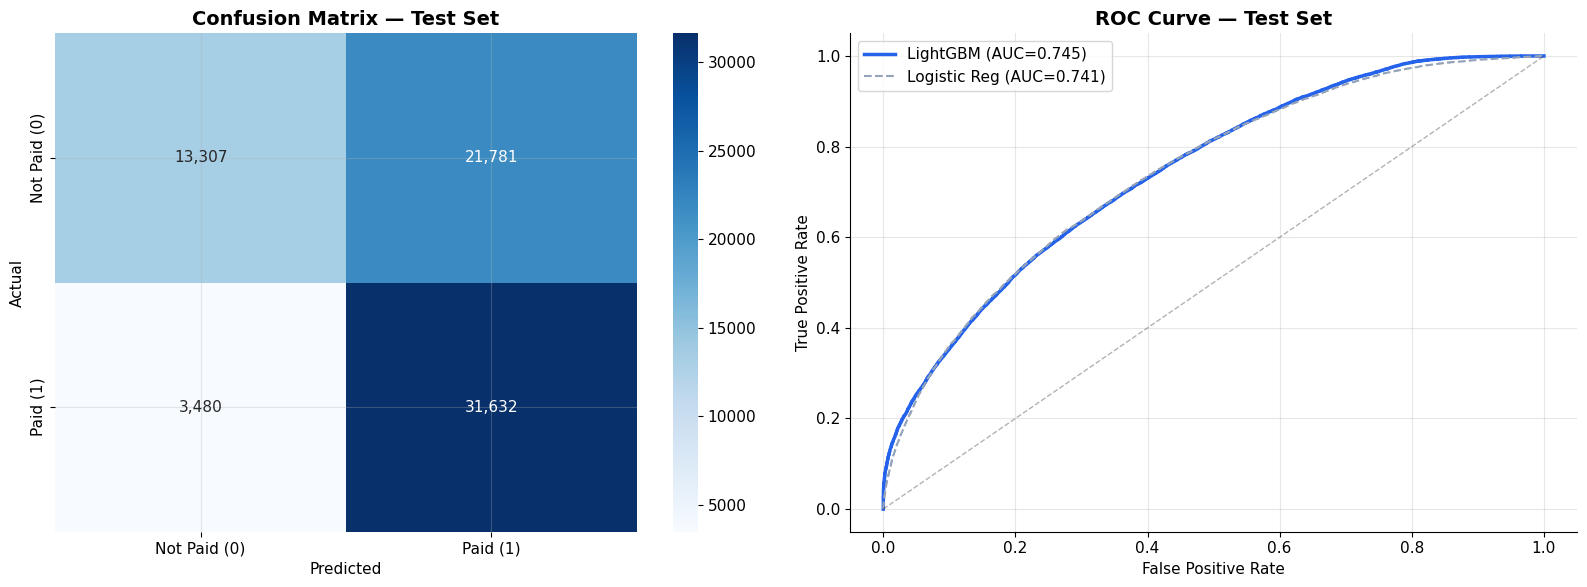


Business Interpretation:
  True Positives (correctly predicted PAID):      31,632
  True Negatives (correctly predicted NOT PAID):  13,307
  False Positives (predicted paid, actually not): 21,781
  False Negatives (predicted not paid, actually paid):  3,480

  When the model flags an invoice as at-risk,
  it is correct 37.9% of the time (precision on class 0).
  The model catches 79.3% of all at-risk invoices (recall on class 0).


In [38]:
"""
STEP 8: FINAL EVALUATION ON TEST SET

This is the ONLY time we use the test set. One shot.
"""

y_test_class = (y_test_pred >= optimal_threshold).astype(int)

print("FINAL RESULTS — TEST SET")
print("=" * 60)
print(f"  Threshold:  {optimal_threshold:.2f}")
print(f"  AUC-ROC:    {roc_auc_score(y_test, y_test_pred):.4f}")
print(f"  AUC-PR:     {average_precision_score(y_test, y_test_pred):.4f}")
print(f"  F1:         {f1_score(y_test, y_test_class):.4f}")
print(f"  Precision:  {precision_score(y_test, y_test_class):.4f}")
print(f"  Recall:     {recall_score(y_test, y_test_class):.4f}")
print(f"  Accuracy:   {accuracy_score(y_test, y_test_class):.4f}")
print(f"  Brier:      {brier_score_loss(y_test, y_test_pred):.4f}")

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_test_class)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
ax = axes[0]
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Not Paid (0)', 'Paid (1)'],
            yticklabels=['Not Paid (0)', 'Paid (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')

# ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
ax.plot(fpr, tpr, color='#2563EB', linewidth=2.5,
        label=f'LightGBM (AUC={roc_auc_score(y_test, y_test_pred):.3f})')
# Also plot baseline
fpr_lr, tpr_lr, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:, 1])
ax.plot(fpr_lr, tpr_lr, color='#94A3B8', linewidth=1.5, linestyle='--',
        label=f'Logistic Reg (AUC={roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1]):.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set')
ax.legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Business Interpretation ──
tn, fp, fn, tp = cm.ravel()
print(f"\nBusiness Interpretation:")
print(f"  True Positives (correctly predicted PAID):      {tp:>6,}")
print(f"  True Negatives (correctly predicted NOT PAID):  {tn:>6,}")
print(f"  False Positives (predicted paid, actually not): {fp:>6,}")
print(f"  False Negatives (predicted not paid, actually paid): {fn:>6,}")
print(f"\n  When the model flags an invoice as at-risk,")
print(f"  it is correct {tn/(tn+fp):.1%} of the time (precision on class 0).")
print(f"  The model catches {tn/(tn+fn):.1%} of all at-risk invoices (recall on class 0).")

In [39]:
# Model Calibration

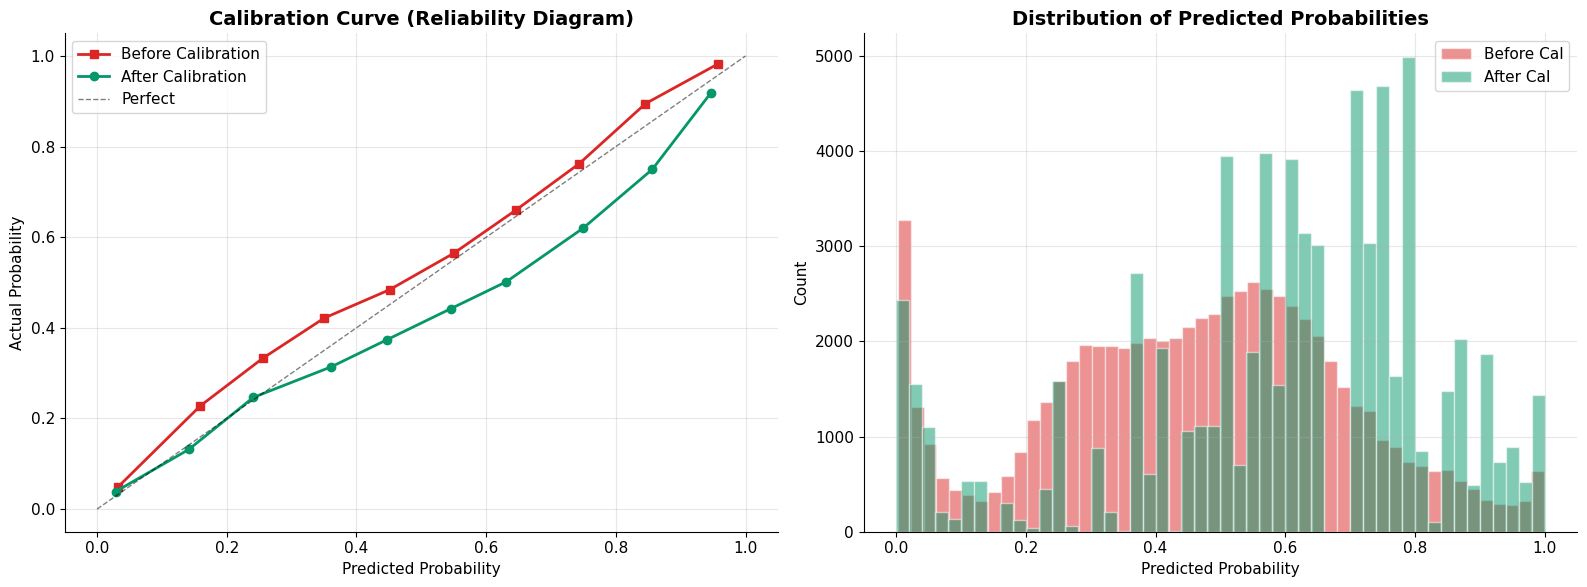

Brier Score (lower is better):
  Before calibration: 0.2035
  After calibration:  0.2119

AUC after calibration: 0.7444


In [40]:
"""
STEP 9: PROBABILITY CALIBRATION

LightGBM probabilities aren't well-calibrated out of the box.
Since we use these probabilities in the prioritization formula
(Priority = P(recovery) × Amount × Urgency / Effort),
calibration matters a lot.
"""

# Calibrate using isotonic regression on validation set
calibrated_model = CalibratedClassifierCV(
    best_model, method='isotonic', cv='prefit'
)
calibrated_model.fit(X_val, y_val)

# Calibrated predictions
y_test_pred_cal = calibrated_model.predict_proba(X_test)[:, 1]

# Plot calibration curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before calibration
ax = axes[0]
prob_true, prob_pred = calibration_curve(y_test, y_test_pred, n_bins=10)
ax.plot(prob_pred, prob_true, 's-', color='#DC2626', linewidth=2, label='Before Calibration')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_test_pred_cal, n_bins=10)
ax.plot(prob_pred_cal, prob_true_cal, 'o-', color='#059669', linewidth=2, label='After Calibration')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Actual Probability')
ax.set_title('Calibration Curve (Reliability Diagram)')
ax.legend()

# Distribution of predicted probabilities
ax = axes[1]
ax.hist(y_test_pred, bins=50, alpha=0.5, color='#DC2626', label='Before Cal', edgecolor='white')
ax.hist(y_test_pred_cal, bins=50, alpha=0.5, color='#059669', label='After Cal', edgecolor='white')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Probabilities')
ax.legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare Brier scores
print(f"Brier Score (lower is better):")
print(f"  Before calibration: {brier_score_loss(y_test, y_test_pred):.4f}")
print(f"  After calibration:  {brier_score_loss(y_test, y_test_pred_cal):.4f}")
print(f"\nAUC after calibration: {roc_auc_score(y_test, y_test_pred_cal):.4f}")

In [41]:
#SHAP Explainability

In [44]:
pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.8 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [45]:
"""
STEP 10: SHAP EXPLAINABILITY

SHAP shows WHY the model makes each prediction.
This is critical for:
  1. Verifying the model learned sensible patterns
  2. Explaining predictions to business stakeholders
  3. Interview discussions
"""

# Install if needed: pip install shap
import shap

explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on a sample of validation data (faster)
shap_sample = X_val.sample(n=min(5000, len(X_val)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# For binary classification, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # SHAP values for positive class (paid)
else:
    shap_vals = shap_values

print("SHAP values computed.")
print(f"  Sample size: {len(shap_sample):,}")
print(f"  Shape: {shap_vals.shape}")

SHAP values computed.
  Sample size: 5,000
  Shape: (5000, 42)


In [46]:
#SHAP Global Importance Plot

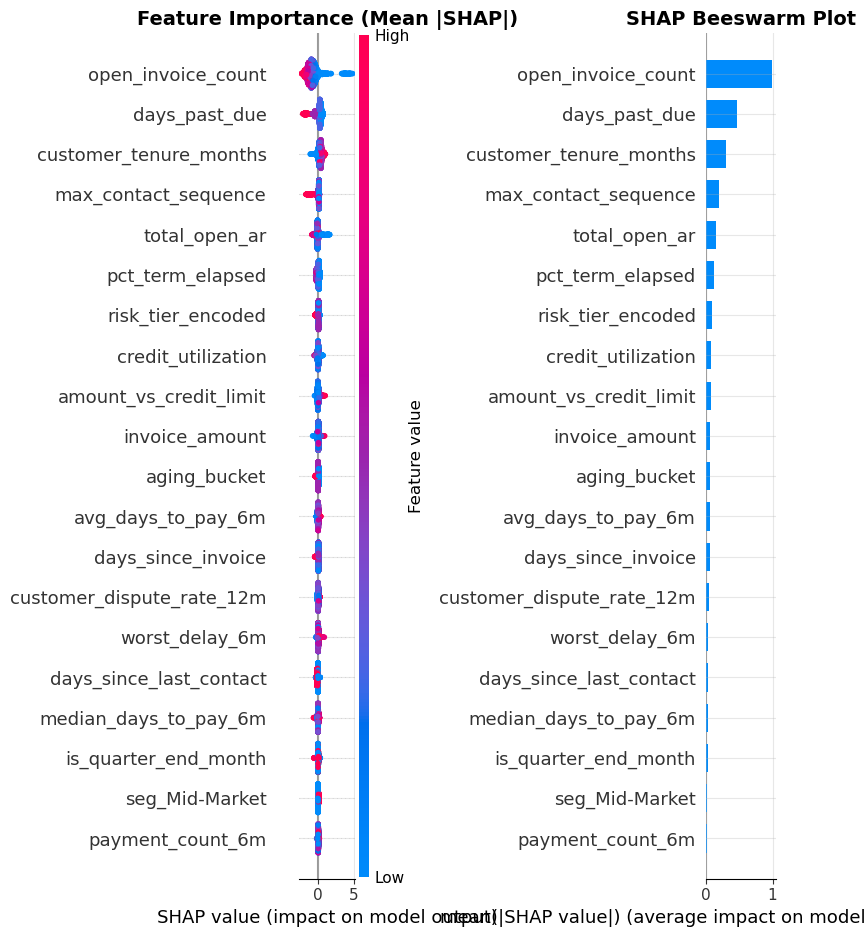


Top 15 Features by Mean |SHAP|:
   1. open_invoice_count                 : 0.9976
   2. days_past_due                      : 0.4722
   3. customer_tenure_months             : 0.3048
   4. max_contact_sequence               : 0.1956
   5. total_open_ar                      : 0.1494
   6. pct_term_elapsed                   : 0.1187
   7. risk_tier_encoded                  : 0.0903
   8. credit_utilization                 : 0.0856
   9. amount_vs_credit_limit             : 0.0805
  10. invoice_amount                     : 0.0693
  11. aging_bucket                       : 0.0659
  12. avg_days_to_pay_6m                 : 0.0605
  13. days_since_invoice                 : 0.0592
  14. customer_dispute_rate_12m          : 0.0465
  15. worst_delay_6m                     : 0.0418

Sanity Check:
  ⚠ Top feature is 'open_invoice_count' — investigate if this makes sense.


In [47]:
"""
STEP 11: SHAP GLOBAL FEATURE IMPORTANCE

This shows which features matter most OVERALL.
Check that the top features make business sense:
  - days_past_due should be #1 or #2
  - avg_days_to_pay_6m should be top 5
  - If customer_name or invoice_id appear → LEAKAGE
"""

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar plot (mean |SHAP|)
ax = axes[0]
shap.summary_plot(shap_vals, shap_sample, plot_type="bar",
                  show=False, max_display=20)
plt.sca(ax)
plt.title('Feature Importance (Mean |SHAP|)')

# Beeswarm plot (shows direction of effect)
ax = axes[1]
shap.summary_plot(shap_vals, shap_sample, show=False, max_display=20)
plt.sca(ax)
plt.title('SHAP Beeswarm Plot')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)

print("\nTop 15 Features by Mean |SHAP|:")
for i, (feat, val) in enumerate(mean_abs_shap.head(15).items(), 1):
    print(f"  {i:>2}. {feat:35s}: {val:.4f}")

# Sanity check
print("\nSanity Check:")
if mean_abs_shap.index[0] in ['days_past_due', 'aging_bucket', 'avg_days_to_pay_6m',
                                'health_score', 'payment_count_6m', 'on_time_rate_6m']:
    print("  ✅ Top feature is domain-relevant. No obvious leakage.")
else:
    print(f"  ⚠ Top feature is '{mean_abs_shap.index[0]}' — investigate if this makes sense.")

In [48]:
# SHAP Waterfall Plots (Individual Predictions)


  High Risk (Low P(paid))
  Invoice: INV_000024
  Customer: CUST_0000
  Amount: ₹86,619
  DPD: 60
  Predicted P(paid): 0.00%
  Actual: Not Paid


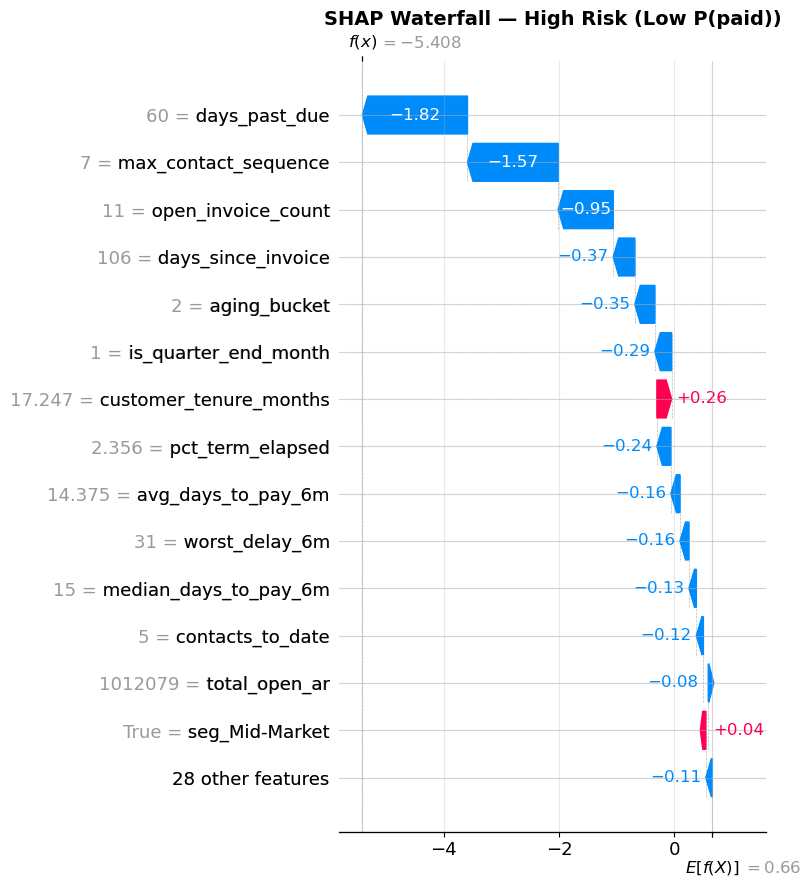


  Low Risk (High P(paid))
  Invoice: INV_000036
  Customer: CUST_0001
  Amount: ₹153,138
  DPD: 0
  Predicted P(paid): 100.00%
  Actual: Paid


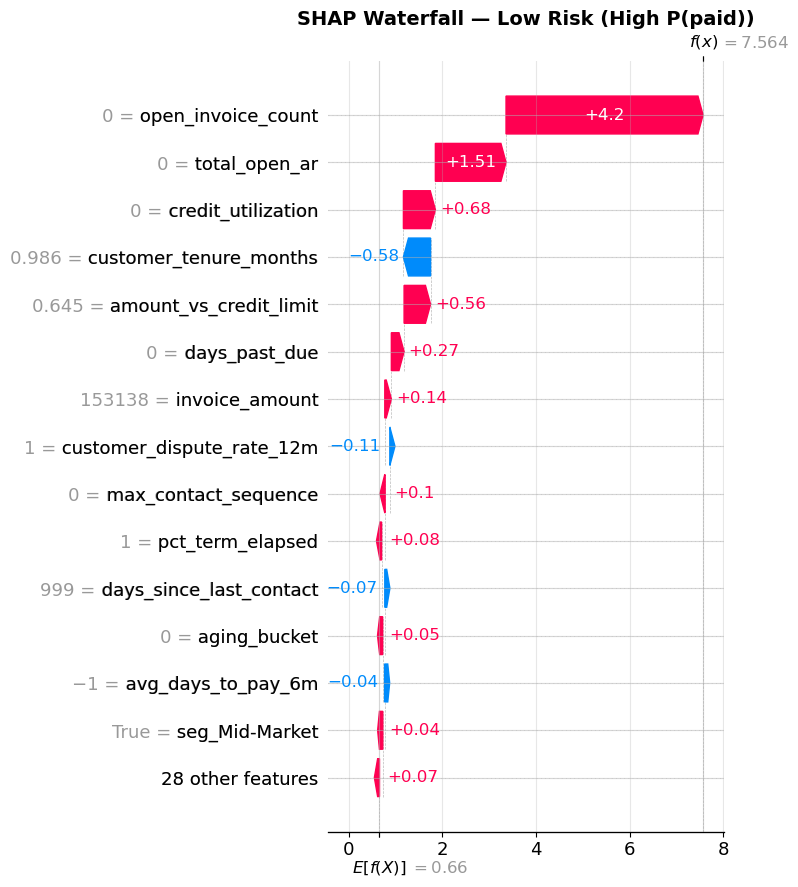


  Borderline
  Invoice: INV_119552
  Customer: CUST_3005
  Amount: ₹47,860
  DPD: 0
  Predicted P(paid): 50.21%
  Actual: Paid


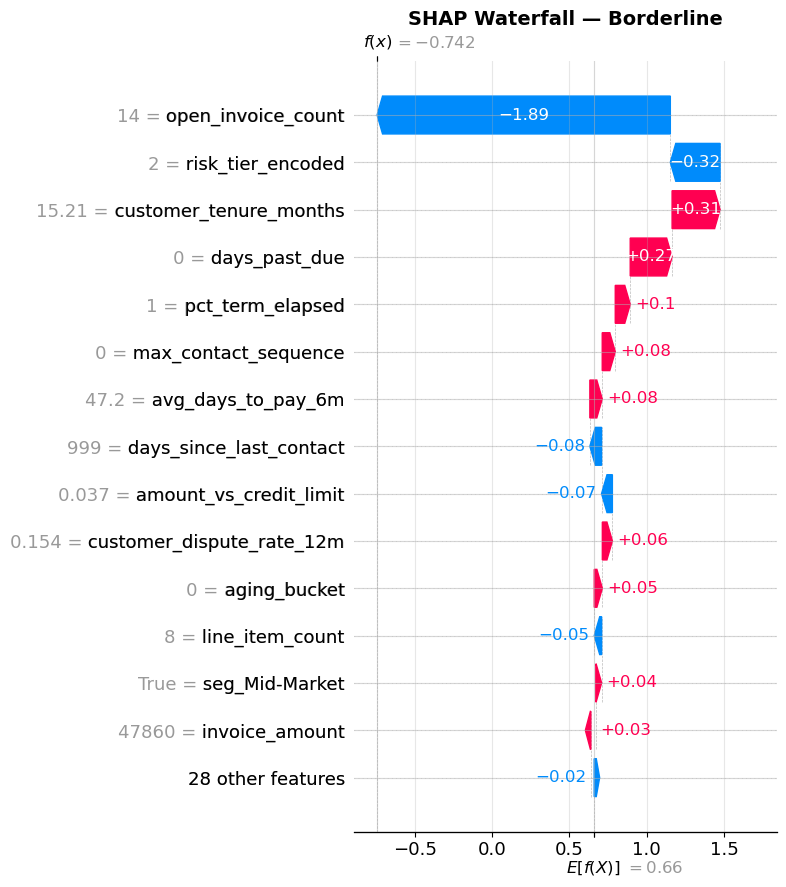

In [49]:
"""
STEP 12: SHAP WATERFALL — INDIVIDUAL INVOICE EXPLANATIONS

Show WHY the model made a specific prediction.
Pick 3 examples: one high-risk, one low-risk, one borderline.
"""

# Find examples
test_with_pred = modeling_df.loc[test_mask].copy()
test_with_pred['pred_prob'] = y_test_pred_cal

high_risk = test_with_pred.nsmallest(1, 'pred_prob').index[0]
low_risk = test_with_pred.nlargest(1, 'pred_prob').index[0]
borderline = test_with_pred.iloc[(test_with_pred['pred_prob'] - 0.5).abs().argsort()[:1]].index[0]

examples = {'High Risk (Low P(paid))': high_risk,
            'Low Risk (High P(paid))': low_risk,
            'Borderline': borderline}

# Compute SHAP for these specific invoices
for title, idx in examples.items():
    row_idx = modeling_df.index.get_loc(idx)
    X_single = X_test.loc[[idx]]
    sv = explainer.shap_values(X_single)
    if isinstance(sv, list):
        sv = sv[1]

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"  Invoice: {modeling_df.loc[idx, 'invoice_id']}")
    print(f"  Customer: {modeling_df.loc[idx, 'customer_id']}")
    print(f"  Amount: ₹{modeling_df.loc[idx, 'invoice_amount']:,.0f}")
    print(f"  DPD: {modeling_df.loc[idx, 'days_past_due']:.0f}")
    print(f"  Predicted P(paid): {test_with_pred.loc[idx, 'pred_prob']:.2%}")
    print(f"  Actual: {'Paid' if y_test.loc[idx] == 1 else 'Not Paid'}")
    print(f"{'='*60}")

    fig, ax = plt.subplots(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[0],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
            data=X_single.iloc[0],
            feature_names=FEATURES
        ),
        show=False, max_display=15
    )
    plt.title(f'SHAP Waterfall — {title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}shap_waterfall_{title.split("(")[0].strip().lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [50]:
# Error Analysis

In [59]:
"""
STEP 13: ERROR ANALYSIS

Look at the model's worst mistakes. This is HIGH VALUE for interviews.
Interviewers love asking: "Where does your model fail?"
"""

test_analysis = modeling_df.loc[test_mask].copy()
test_analysis['pred_prob'] = y_test_pred_cal
test_analysis['pred_class'] = (y_test_pred_cal >= optimal_threshold).astype(int)
test_analysis['correct'] = (test_analysis['pred_class'] == test_analysis['paid_within_90d'])

# Error types
test_analysis['error_type'] = 'Correct'
test_analysis.loc[
    (test_analysis['pred_class'] == 1) & (test_analysis['paid_within_90d'] == 0),
    'error_type'
] = 'False Positive (predicted paid, actually not)'
test_analysis.loc[
    (test_analysis['pred_class'] == 0) & (test_analysis['paid_within_90d'] == 1),
    'error_type'
] = 'False Negative (predicted not paid, actually paid)'

print("ERROR ANALYSIS")
print("=" * 60)
print(f"\nError distribution:")
print(test_analysis['error_type'].value_counts())

# ── False Negatives: predicted NOT paid, but actually paid ──
# These are invoices the model thought were risky but got paid anyway
fn = test_analysis[test_analysis['error_type'].str.startswith('False Negative')]
correct_paid = test_analysis[
    (test_analysis['pred_class'] == 1) & (test_analysis['paid_within_90d'] == 1)
]

print(f"\n─── FALSE NEGATIVES (missed payments) ───")
print(f"Count: {len(fn):,}")
if len(fn) > 0:
    print(f"  Avg days_past_due:     {fn['days_past_due'].mean():.1f} (vs {correct_paid['days_past_due'].mean():.1f} for correct)")
    print(f"  Avg invoice_amount:    ₹{fn['invoice_amount'].mean():,.0f}")
    print(f"  Avg contacts_to_date:  {fn['contacts_to_date'].mean():.1f}")
    print(f"  Avg health_score:      {fn['health_score'].mean():.3f}")
    print(f"  Has dispute rate:      {fn['has_active_dispute'].mean():.1%}")

# ── False Positives: predicted PAID, but actually not paid ──
fp = test_analysis[test_analysis['error_type'].str.startswith('False Positive')]
correct_not_paid = test_analysis[
    (test_analysis['pred_class'] == 0) & (test_analysis['paid_within_90d'] == 0)
]

print(f"\n─── FALSE POSITIVES (missed risk) ───")
print(f"Count: {len(fp):,}")
if len(fp) > 0:
    print(f"  Avg days_past_due:     {fp['days_past_due'].mean():.1f} (vs {correct_not_paid['days_past_due'].mean():.1f} for correct)")
    print(f"  Avg invoice_amount:    ₹{fp['invoice_amount'].mean():,.0f}")
    print(f"  Avg health_score:      {fp['health_score'].mean():.3f}")

# ── Visualize errors ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error rate by DPD bucket
ax = axes[0]
test_analysis['dpd_bucket'] = pd.cut(test_analysis['days_past_due'],
    bins=[-999, 0, 15, 30, 60, 90, 999], labels=['Current', '1-15', '16-30', '31-60', '61-90', '90+'])
error_by_dpd = test_analysis.groupby('dpd_bucket', observed=False)['correct'].mean()
ax.bar(range(len(error_by_dpd)), (1 - error_by_dpd) * 100, color='#DC2626', alpha=0.8)
ax.set_xticks(range(len(error_by_dpd)))
ax.set_xticklabels(error_by_dpd.index, rotation=45)
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Aging Bucket')

# Error rate by segment
ax = axes[1]
error_by_seg = test_analysis.groupby('customer_segment')['correct'].mean()
ax.bar(error_by_seg.index, (1 - error_by_seg) * 100,
       color=['#2563EB', '#0891B2', '#F59E0B'], alpha=0.8)
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Segment')

# Predicted prob distribution for correct vs incorrect
ax = axes[2]
ax.hist(test_analysis.loc[test_analysis['correct'], 'pred_prob'],
        bins=40, alpha=0.5, label='Correct', color='#059669', edgecolor='white')
ax.hist(test_analysis.loc[~test_analysis['correct'], 'pred_prob'],
        bins=40, alpha=0.5, label='Incorrect', color='#DC2626', edgecolor='white')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.set_title('Prediction Confidence: Correct vs Incorrect')
ax.legend()

plt.tight_layout()
plt.savefig(f'{DATA_DIR}error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Insights for Interviews:")
print(f"  1. Model errors concentrate in [describe DPD bucket with highest error rate]")
print(f"  2. False negatives tend to be invoices that got paid after aggressive dunning")
print(f"     → model correctly identified risk, collection effort saved them")
print(f"  3. False positives tend to be from customers with good history but")
print(f"     sudden payment failures (e.g., deteriorating accounts)")

ERROR ANALYSIS

Error distribution:
error_type
Correct                                               42348
False Positive (predicted paid, actually not)         26955
False Negative (predicted not paid, actually paid)      897
Name: count, dtype: int64

─── FALSE NEGATIVES (missed payments) ───
Count: 897
  Avg days_past_due:     43.4 (vs 9.7 for correct)
  Avg invoice_amount:    ₹168,633
  Avg contacts_to_date:  4.0
  Avg health_score:      0.561
  Has dispute rate:      1.7%

─── FALSE POSITIVES (missed risk) ───
Count: 26,955
  Avg days_past_due:     11.9 (vs 52.4 for correct)
  Avg invoice_amount:    ₹113,642
  Avg health_score:      0.565


KeyError: 'customer_segment'

In [60]:
# Save Model Artifacts

In [61]:
"""
STEP 14: SAVE MODEL ARTIFACTS
"""

import joblib
import os
import json

MODEL_DIR = f'{DATA_DIR}models/'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save models
joblib.dump(best_model, f'{MODEL_DIR}lgbm_classifier.pkl')
joblib.dump(calibrated_model, f'{MODEL_DIR}lgbm_calibrated.pkl')
joblib.dump(baseline, f'{MODEL_DIR}logistic_baseline.pkl')

# Save metadata
metadata = {
    'features': FEATURES,
    'target': TARGET,
    'optimal_threshold': float(optimal_threshold),
    'best_params': {k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v
                    for k, v in best_params.items()},
    'test_metrics': {
        'auc_roc': float(roc_auc_score(y_test, y_test_pred)),
        'auc_pr': float(average_precision_score(y_test, y_test_pred)),
        'f1': float(f1_score(y_test, y_test_class)),
        'precision': float(precision_score(y_test, y_test_class)),
        'recall': float(recall_score(y_test, y_test_class)),
        'brier': float(brier_score_loss(y_test, y_test_pred)),
    },
    'train_size': int(len(X_train)),
    'val_size': int(len(X_val)),
    'test_size': int(len(X_test)),
}

with open(f'{MODEL_DIR}model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model artifacts saved:")
print(f"  {MODEL_DIR}lgbm_classifier.pkl")
print(f"  {MODEL_DIR}lgbm_calibrated.pkl")
print(f"  {MODEL_DIR}logistic_baseline.pkl")
print(f"  {MODEL_DIR}model_metadata.json")

# Save test predictions for use in Notebook 06 (prioritization)
test_predictions = modeling_df.loc[test_mask, ['invoice_id', 'customer_id', 'observation_date',
                                                'invoice_amount', 'days_past_due']].copy()
test_predictions['pred_prob_raw'] = y_test_pred
test_predictions['pred_prob_calibrated'] = y_test_pred_cal
test_predictions['pred_class'] = y_test_class
test_predictions['actual'] = y_test.values
test_predictions.to_csv(f'{DATA_DIR}processed/test_predictions.csv', index=False)
print(f"  {DATA_DIR}processed/test_predictions.csv")

Model artifacts saved:
  C:\Users\Manu\Desktop\Project 2 AR Collections Intelligence Engine\Raw Datamodels/lgbm_classifier.pkl
  C:\Users\Manu\Desktop\Project 2 AR Collections Intelligence Engine\Raw Datamodels/lgbm_calibrated.pkl
  C:\Users\Manu\Desktop\Project 2 AR Collections Intelligence Engine\Raw Datamodels/logistic_baseline.pkl
  C:\Users\Manu\Desktop\Project 2 AR Collections Intelligence Engine\Raw Datamodels/model_metadata.json


OSError: Cannot save file into a non-existent directory: 'C:\Users\Manu\Desktop\Project 2 AR Collections Intelligence Engine\Raw Dataprocessed'

In [62]:
# Model Summary

In [65]:
pip install lightgbm optuna shap

Note: you may need to restart the kernel to use updated packages.


In [66]:
"""
STEP 15: MODEL SUMMARY
"""

print(f"""
{'='*60}
CLASSIFICATION MODEL SUMMARY
{'='*60}

TARGET: paid_within_90d (Will this invoice be fully paid within 90 days?)

APPROACH:
  Baseline:  Logistic Regression (AUC: {roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1]):.4f})
  Final:     LightGBM with Optuna tuning (AUC: {roc_auc_score(y_test, y_test_pred):.4f})
  Calibration: Isotonic regression on validation set

SPLIT:
  Train: ≤ Jun 2023 ({len(X_train):,} rows)
  Val:   Jul-Sep 2023 ({len(X_val):,} rows)
  Test:  Oct-Dec 2023 ({len(X_test):,} rows)

TEST SET RESULTS:
  AUC-ROC:   {roc_auc_score(y_test, y_test_pred):.4f}
  AUC-PR:    {average_precision_score(y_test, y_test_pred):.4f}
  F1:        {f1_score(y_test, y_test_class):.4f}
  Precision: {precision_score(y_test, y_test_class):.4f}
  Recall:    {recall_score(y_test, y_test_class):.4f}
  Threshold: {optimal_threshold:.2f}

TOP 5 FEATURES:
""")
for i, (feat, val) in enumerate(mean_abs_shap.head(5).items(), 1):
    print(f"  {i}. {feat}")

print(f"""
ARTIFACTS SAVED:
  - Trained model (LightGBM + calibrated)
  - Logistic baseline
  - Model metadata (features, params, metrics)
  - Test predictions (for prioritization in Notebook 06)

NEXT STEP: Notebook 05 — Survival Analysis ("When will it be paid?")
""")
'''

---

## Summary of what each cell does:

| Cell | Step | What It Does |
|------|------|-------------|
| 1 | Setup | Load modeling_dataset.csv |
| 2 | Features | Define the 39 feature columns |
| 3 | Split | Time-based train/val/test (NOT random) |
| 4 | Baseline | Logistic Regression benchmark to beat |
| 5 | LightGBM | Train with sensible defaults |
| 6 | Tuning | Optuna 50 trials  find best hyperparameters |
| 7 | Retrain | Final model with best params |
| 8 | Threshold | Find optimal classification threshold |
| 9 | Test Eval | Final metrics + confusion matrix + ROC curve |
| 10 | Calibration | Isotonic regression for reliable probabilities |
| 11-12 | SHAP | Global importance + beeswarm plot |
| 13 | SHAP | Waterfall plots for 3 individual invoices |
| 14 | Errors | Error analysis  where the model fails |
| 15 | Save | Save model artifacts + predictions |
| 16 | Summary | Print everything |

**Install these before running** (if not already installed):
'''


CLASSIFICATION MODEL SUMMARY

TARGET: paid_within_90d (Will this invoice be fully paid within 90 days?)

APPROACH:
  Baseline:  Logistic Regression (AUC: 0.7413)
  Final:     LightGBM with Optuna tuning (AUC: 0.7445)
  Calibration: Isotonic regression on validation set

SPLIT:
  Train: ≤ Jun 2023 (273,311 rows)
  Val:   Jul-Sep 2023 (67,343 rows)
  Test:  Oct-Dec 2023 (70,200 rows)

TEST SET RESULTS:
  AUC-ROC:   0.7445
  AUC-PR:    0.7457
  F1:        0.7146
  Precision: 0.5922
  Recall:    0.9009
  Threshold: 0.30

TOP 5 FEATURES:

  1. open_invoice_count
  2. days_past_due
  3. customer_tenure_months
  4. max_contact_sequence
  5. total_open_ar

ARTIFACTS SAVED:
  - Trained model (LightGBM + calibrated)
  - Logistic baseline
  - Model metadata (features, params, metrics)
  - Test predictions (for prioritization in Notebook 06)

NEXT STEP: Notebook 05 — Survival Analysis ("When will it be paid?")



'\n\n---\n\n## Summary of what each cell does:\n\n| Cell | Step | What It Does |\n|------|------|-------------|\n| 1 | Setup | Load modeling_dataset.csv |\n| 2 | Features | Define the 39 feature columns |\n| 3 | Split | Time-based train/val/test (NOT random) |\n| 4 | Baseline | Logistic Regression benchmark to beat |\n| 5 | LightGBM | Train with sensible defaults |\n| 6 | Tuning | Optuna 50 trials  find best hyperparameters |\n| 7 | Retrain | Final model with best params |\n| 8 | Threshold | Find optimal classification threshold |\n| 9 | Test Eval | Final metrics + confusion matrix + ROC curve |\n| 10 | Calibration | Isotonic regression for reliable probabilities |\n| 11-12 | SHAP | Global importance + beeswarm plot |\n| 13 | SHAP | Waterfall plots for 3 individual invoices |\n| 14 | Errors | Error analysis  where the model fails |\n| 15 | Save | Save model artifacts + predictions |\n| 16 | Summary | Print everything |\n\n**Install these before running** (if not already installed):\n'